# Deep Learning Fundamentals - Mini-Project

## MNIST Digits - Ambiguous and Confident-Wrong

In [1]:
import os, json, math
from typing import Tuple, Optional, List, Dict

import torch
from torch import Tensor
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import MNIST
import matplotlib.pyplot as plt

import lightning as L
from lightning.pytorch.core import LightningModule

from mnist_mlp_classifier import MNISTMLP
# from mnist_cnn_classifier import MNISTCNN

In [2]:
if torch.cuda.is_available():
    torch.set_float32_matmul_precision("high")

/home/logus/env/iscte/mnist_digits/lib/python3.10/site-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  _C._set_float32_matmul_precision(precision)


In [3]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CHECKPOINT_FILEPATH = "checkpoints/mnist_mlp_best.ckpt"
# CHECKPOINT_FILEPATH = "checkpoints/mnist_cnn_best.ckpt"
SEED = L.seed_everything(42)

Seed set to 42


## Dataset loader

In [4]:
class EvalData:
    def __init__(self, data_dir: str = "./datasets", batch_size: int = 256, num_workers: int = 0):
        self.tfm = transforms.ToTensor()  # no Normalize, to match training choice
        self.test = MNIST(data_dir, train=False, download=True, transform=self.tfm)
        self.loader = DataLoader(self.test, batch_size=batch_size, shuffle=False,
                                 num_workers=num_workers, pin_memory=(DEVICE=="cuda"))


## Model loader, picks the most recent checkpoint

In [5]:
model = MNISTMLP.load_from_checkpoint(CHECKPOINT_FILEPATH).eval().to(DEVICE)
# model = MNISTCNN.load_from_checkpoint(CHECKPOINT_FILEPATH).eval().to(DEVICE)

In [6]:
# Create the data object
data = EvalData(batch_size=512, num_workers=0)

## Score the test set, only once (cache logits & labels)

In [7]:
@torch.no_grad()
def score_dataset(model: LightningModule, loader: DataLoader) -> Tuple[Tensor, Tensor]:
    logits_list, labels_list = [], []
    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        logits = model(xb)                 # [B, 10]
        logits_list.append(logits.cpu())
        labels_list.append(yb.cpu())
    logits = torch.cat(logits_list, dim=0)     # [N, 10]
    labels = torch.cat(labels_list, dim=0)     # [N]
    return logits, labels

## Uncertainty evaluation: max-prob, margin, entropy

In [8]:
def probs_from_logits(logits: Tensor, temperature: float = 1.0) -> Tensor:
    if temperature != 1.0:
        logits = logits / float(temperature)
    return logits.softmax(dim=1)

def uncertainty_scores(probs: Tensor) -> Dict[str, Tensor]:
    # probs: [N, 10]
    pmax, pred = probs.max(dim=1)     # [N], [N]
    top2 = probs.topk(2, dim=1).values
    margin = top2[:, 0] - top2[:, 1]  # [N]
    entropy = (-probs * (probs.clamp_min(1e-12)).log()).sum(dim=1)  # [N]
    return {"pmax": pmax, "pred": pred, "margin": margin, "entropy": entropy}


## Filters for ambiguous and confident-wrong

In [9]:
def find_ambiguous(
    probs: Tensor,
    labels: Optional[Tensor] = None,
    max_prob_th: float = 0.6,
    margin_th: float = 0.05,
    topk: int = 3,
) -> List[Dict]:
    """
    Return a list of dicts with indices and scores for 'ambiguous' samples.
    """
    N, C = probs.shape
    s = uncertainty_scores(probs)
    ambiguous_mask = (s["pmax"] < max_prob_th) | (s["margin"] < margin_th)
    idxs = ambiguous_mask.nonzero(as_tuple=False).squeeze(1).tolist()

    out = []
    tk_vals, tk_idx = probs.topk(min(topk, C), dim=1)
    for i in idxs:
        rec = {
            "idx": i,
            "pred": int(s["pred"][i]),
            "pmax": float(s["pmax"][i]),
            "margin": float(s["margin"][i]),
            "entropy": float(s["entropy"][i]),
            "topk": [int(x) for x in tk_idx[i].tolist()],
            "topk_probs": [float(x) for x in tk_vals[i].tolist()],
        }
        if labels is not None:
            rec["true"] = int(labels[i])
            rec["is_correct"] = (rec["pred"] == rec["true"])
        out.append(rec)

    # Sort by highest entropy, then smallest margin
    out.sort(key=lambda r: (-r["entropy"], r["margin"]))
    return out

def find_confident_wrong(
    probs: Tensor,
    labels: Tensor,
    hi: float = 0.95,
    lo: float = 0.05,
    topk: int = 3,
) -> List[Dict]:
    """
    Flag likely mislabeled: pred != y_true AND p_pred >= hi AND p_true <= lo
    """
    s = uncertainty_scores(probs)
    p_pred = s["pmax"]
    pred = s["pred"]
    p_true = probs[torch.arange(labels.numel()), labels]
    mask = (pred != labels) & (p_pred >= hi) & (p_true <= lo)
    idxs = mask.nonzero(as_tuple=False).squeeze(1).tolist()

    tk_vals, tk_idx = probs.topk(min(topk, probs.size(1)), dim=1)
    out = []
    for i in idxs:
        out.append({
            "idx": i,
            "true": int(labels[i]),
            "pred": int(pred[i]),
            "p_pred": float(p_pred[i]),
            "p_true": float(p_true[i]),
            "topk": [int(x) for x in tk_idx[i].tolist()],
            "topk_probs": [float(x) for x in tk_vals[i].tolist()],
        })
    # Sort: strongest “confident wrong” first (high p_pred, low p_true)
    out.sort(key=lambda r: (-r["p_pred"], r["p_true"]))
    return out

## Viewer for quick inspection (grid with top-k)

In [10]:
def show_samples_grid(
    dataset: MNIST,
    probs: Tensor,
    indices: List[int],
    labels: Optional[Tensor] = None,
    cols: int = 5,
    topk: int = 3,
) -> None:
    """
    Render a grid of samples with GT | Pred and top-k probs.
    Correct = green, Wrong = red.
    """
    s = uncertainty_scores(probs)
    rows = math.ceil(len(indices)/cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols*2.4, rows*2.8))
    
    # Handle the case where subplots returns a single Axes object or an array of Axes
    # Check if axes is array-like (numpy array or similar) that has a ravel method
    if hasattr(axes, 'ravel'):
        axes = axes.ravel()
    else:
        # If it's a single Axes object (when rows*cols == 1), make it a list
        axes = [axes] if rows * cols == 1 else axes.flatten() # flatten() handles other array shapes too


    tk_vals, tk_idx = probs.topk(min(topk, probs.size(1)), dim=1)

    for j, ax in enumerate(axes):
        ax.axis("off")
        if j >= len(indices): continue
        i = indices[j]
        img, y = dataset[i]
        ax.imshow(img.squeeze(0), cmap="gray", interpolation="nearest")
        pred = int(s["pred"][i])
        title = f"Pred {pred}"
        color = "black"
        if labels is not None:
            yt = int(labels[i])
            ok = (pred == yt)
            color = "green" if ok else "red"
            title = f"GT {yt} | Pred {pred}"

        ax.set_title(title, fontsize=9, color=color)
        # small top-k text
        tks = [f"{c}:{p:.2f}" for c, p in zip(tk_idx[i].tolist(), tk_vals[i].tolist())]
        ax.text(0.02, 0.02, " ".join(tks), transform=ax.transAxes, fontsize=8,
                color="blue", bbox=dict(facecolor="white", alpha=0.6, lw=0))

    plt.tight_layout()
    plt.show()

## Load, score and list ambiguous

Ambiguous found: 3576
Confident-wrong found: 16


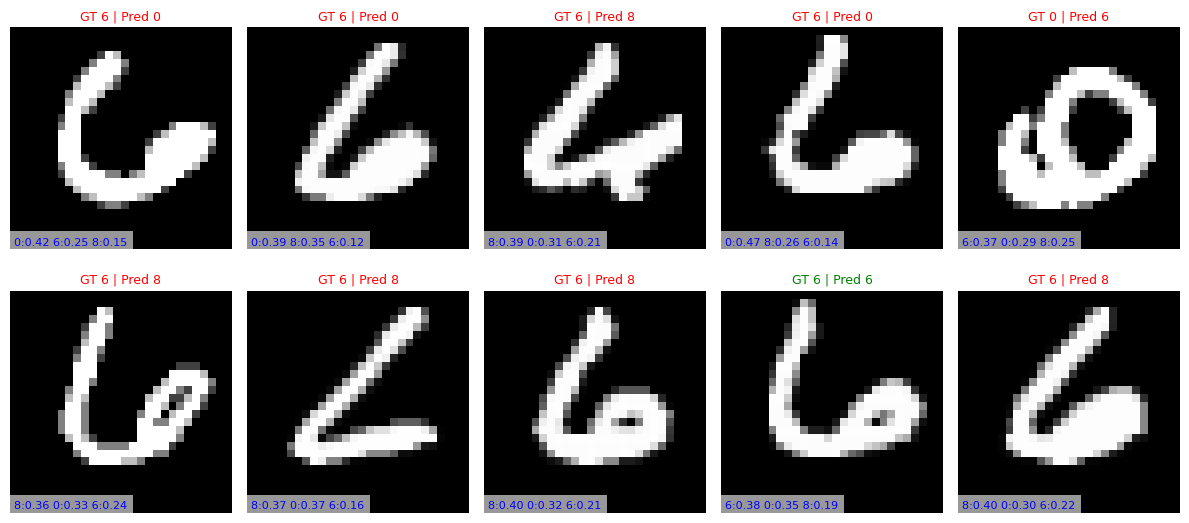

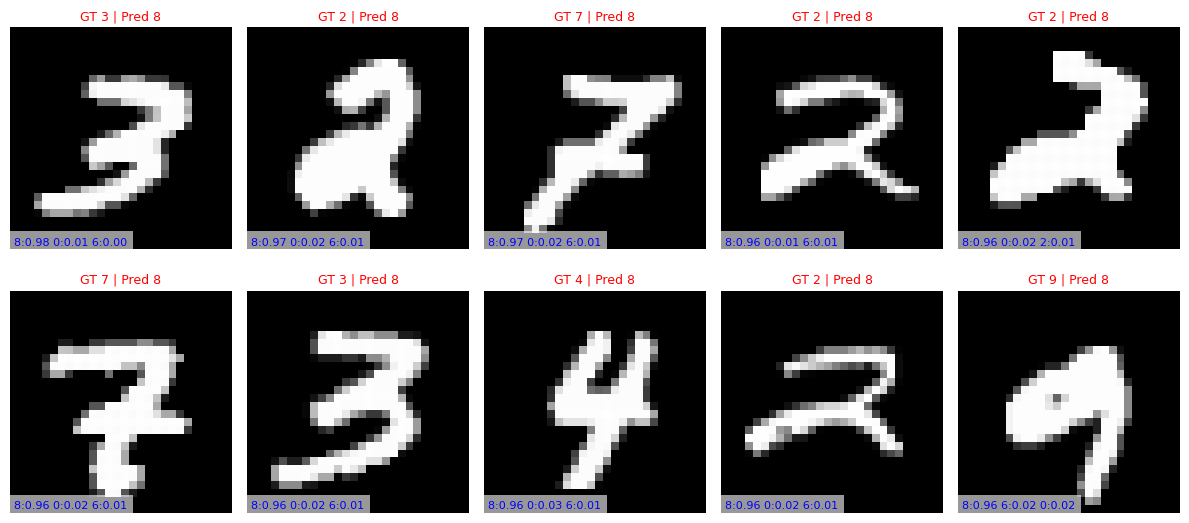

In [11]:
# Score once
logits, labels = score_dataset(model, data.loader) # 'data' is available here from the previous cell/block
probs = probs_from_logits(logits)  # no temperature scaling (yet)

# Lists
amb = find_ambiguous(probs, labels, max_prob_th=0.6, margin_th=0.05, topk=3)
confw = find_confident_wrong(probs, labels, hi=0.95, lo=0.05, topk=3)

print(f"Ambiguous found: {len(amb)}")
print(f"Confident-wrong found: {len(confw)}")

# Preview a few
amb_idxs = [r["idx"] for r in amb[:10]]
confw_idxs = [r["idx"] for r in confw[:10]]

show_samples_grid(data.test, probs, amb_idxs, labels, cols=5, topk=3)
show_samples_grid(data.test, probs, confw_idxs, labels, cols=5, topk=3)

## Save review lists

In [12]:
def save_jsonl(path: str, rows: List[Dict]) -> None:
    with open(path, "w", encoding="utf-8") as f:
        for r in rows:
            f.write(json.dumps(r) + "\n")

filename = os.path.basename(CHECKPOINT_FILEPATH)
# Remove .ckpt extension to get the base name (any given name or a timestamp)
name_without_ext = os.path.splitext(filename)[0]
ts = name_without_ext

os.makedirs("review", exist_ok=True)
save_jsonl(f"review/{ts}_ambiguous.jsonl", amb)
save_jsonl(f"review/{ts}_confident_wrong.jsonl", confw)
print("Saved under review/")

Saved under review/
